# Final problem

We will do two exercises:

1. Create a film recommendation system using word embeddings:
    - Explain how would you create a recommendation system for films using word embeddings. Which variables would you use? How to represent the data? Which techniques/algorithms would you use to represent the films and to compute similarities between them? Dataset: You can use the [Wikipedia Movie Plots dataset](https://www.kaggle.com/datasets/jrobischon/wikipedia-movie-plots).
2. Sentiment analysis of film reviews:
    - Explain how would you create a sentiment analysis model for film reviews. How would you preprocess the data? How would you represent the reviews? Which model architecture would you choose and why? How would you evaluate the model's performance? Dataset: You can use the [IMDb movie reviews dataset](https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews).

## 1. Film recommendation system using word embeddings

### 1.1 Loading the dataset

In [71]:
import opendatasets as od
import pandas as pd
pd.set_option('display.max_colwidth', None)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud
import re
import gensim.downloader
from gensim.models import Word2Vec
from gensim.parsing.preprocessing import preprocess_string
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Dense, Dropout, Embedding, Flatten, LSTM
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from transformers import BertTokenizer, TFBertModel
from sklearn.model_selection import train_test_split
from scipy.special import softmax

# uv run python -m spacy download en_core_web_sm
nlp = spacy.load("en_core_web_sm")
nltk.download('vader_lexicon')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /home/javier/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package stopwords to /home/javier/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/javier/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /home/javier/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/javier/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /home/javier/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

In [15]:
movie_plots_dataset = pd.read_csv('datasets/wiki_movie_plots_deduped.csv')
movie_plots_dataset.head()

,Release Year,Title,Origin/Ethnicity,Director,Cast,Genre,Wiki Page,Plot
0,1901,Kansas Saloon Smashers,American,Unknown,NaN,unknown,https://en.wikipedia.org/wiki/Kansas_Saloon_Smashers,"A bartender is working at a saloon, serving drinks to customers. After he fills a stereotypically Irish man's bucket with beer, Carrie Nation and her followers burst inside. They assault the Irish man, pulling his hat over his eyes and then dumping the beer over his head. The group then begin wrecking the bar, smashing the fixtures, mirrors, and breaking the cash register. The bartender then sprays seltzer water in Nation's face before a group of policemen appear and order everybody to leave.[1]"
1,1901,Love by the Light of the Moon,American,Unknown,NaN,unknown,https://en.wikipedia.org/wiki/Love_by_the_Light_of_the_Moon,"The moon, painted with a smiling face hangs over a park at night. A young couple walking past a fence learn on a railing and look up. The moon smiles. They embrace, and the moon's smile gets bigger. They then sit down on a bench by a tree. The moon's view is blocked, causing him to frown. In the last scene, the man fans the woman with his hat because the moon has left the sky and is perched over her shoulder to see everything better."
2,1901,The Martyred Presidents,American,Unknown,NaN,unknown,https://en.wikipedia.org/wiki/The_Martyred_Presidents,"The film, just over a minute long, is composed of two shots. In the first, a girl sits at the base of an altar or tomb, her face hidden from the camera. At the center of the altar, a viewing portal displays the portraits of three U.S. Presidents—Abraham Lincoln, James A. Garfield, and William McKinley—each victims of assassination.\r\nIn the second shot, which runs just over eight seconds long, an assassin kneels feet of Lady Justice."
3,1901,"Terrible Teddy, the Grizzly King",American,Unknown,NaN,unknown,"https://en.wikipedia.org/wiki/Terrible_Teddy,_the_Grizzly_King","Lasting just 61 seconds and consisting of two shots, the first shot is set in a wood during winter. The actor representing then vice-president Theodore Roosevelt enthusiastically hurries down a hillside towards a tree in the foreground. He falls once, but rights himself and cocks his rifle. Two other men, bearing signs reading ""His Photographer"" and ""His Press Agent"" respectively, follow him into the shot; the photographer sets up his camera. ""Teddy"" aims his rifle upward at the tree and fells what appears to be a common house cat, which he then proceeds to stab. ""Teddy"" holds his prize aloft, and the press agent takes notes. The second shot is taken in a slightly different part of the wood, on a path. ""Teddy"" rides the path on his horse towards the camera and out to the left of the shot, followed closely by the press agent and photographer, still dutifully holding their signs."
4,1902,Jack and the Beanstalk,American,"George S. Fleming, Edwin S. Porter",NaN,unknown,https://en.wikipedia.org/wiki/Jack_and_the_Beanstalk_(1902_film),"The earliest known adaptation of the classic fairytale, this films shows Jack trading his cow for the beans, his mother forcing him to drop them in the front yard, and beig forced upstairs. As he sleeps, Jack is visited by a fairy who shows him glimpses of what will await him when he ascends the bean stalk. In this version, Jack is the son of a deposed king. When Jack wakes up, he finds the beanstalk has grown and he climbs to the top where he enters the giant's home. The giant finds Jack, who narrowly escapes. The giant chases Jack down the bean stalk, but Jack is able to cut it down before the giant can get to safety. He falls and is killed as Jack celebrates. The fairy then reveals that Jack may return home as a prince."


### 1.2. Analysis of the dataset and Cleaning

In [16]:
print(f"dataset size: {movie_plots_dataset.shape}")
print(movie_plots_dataset.columns)
print("Null values per column:")
print(movie_plots_dataset.isnull().sum())
print("Unknown values per column:")
print((movie_plots_dataset == 'unknown').sum())

dataset size: (34886, 8)
Index(['Release Year', 'Title', 'Origin/Ethnicity', 'Director', 'Cast',
       'Genre', 'Wiki Page', 'Plot'],
      dtype='object')
Null values per column:
Release Year           0
Title                  0
Origin/Ethnicity       0
Director               0
Cast                1422
Genre                  0
Wiki Page              0
Plot                   0
dtype: int64
Unknown values per column:
Release Year           0
Title                  0
Origin/Ethnicity       0
Director               0
Cast                   0
Genre               6083
Wiki Page              0
Plot                   0
dtype: int64


In [17]:
print("Cast unique values:")
print(len(movie_plots_dataset['Cast'].unique().tolist()))
print("Percentage of 'NaN' values in Cast column:")
print(movie_plots_dataset['Cast'].isna().mean() * 100)

Cast unique values:
32183
Percentage of 'NaN' values in Cast column:
4.07613369259875


In [18]:
print("Genre unique values:")
print(len(movie_plots_dataset['Genre'].unique().tolist()))
print("Percentage of 'unknown' values in Genre column:")
unknown_genre_percentage = movie_plots_dataset['Genre'].str.contains('unknown').sum() / movie_plots_dataset.shape[0] * 100
print(f"{unknown_genre_percentage:.2f}%")

Genre unique values:
2265
Percentage of 'unknown' values in Genre column:
17.44%


In [19]:
print("Release year range:")
print(movie_plots_dataset['Release Year'].min(), "-", movie_plots_dataset['Release Year'].max())

Release year range:
1901 - 2017


In [20]:
print("Origin/Ethnicity unique values:")
print(len(movie_plots_dataset['Origin/Ethnicity'].unique().tolist()))

Origin/Ethnicity unique values:
24


In [21]:
print("Director unique values:")
print(len(movie_plots_dataset['Director'].unique().tolist()))

Director unique values:
12593


From the dataset we have several variables that can be useful for creating a recommendation system. The most relevant ones are:
- Title: The name of the movie.
- Plot: A brief summary of the movie's storyline.
- Genre: The category or categories the movie belongs to (e.g., Action, Comedy, Drama). 17% of 'unknown' values. We could consider dropping rows with unknown genre if we find it relevant. It suffers from multi-label classification as some movies have multiple genres.
- Director: The director of the movie.
- Cast: The main actors in the movie. 4% of NaN values. We could consider dropping rows with unknown cast if we find it relevant.
- Release Year: The year the movie was released. Range goes from 1901 to 2017.
- Origin/Ethnicity: The country or region where the movie was produced. It has only 24 unique values, so it might not provide much variability for recommendations if the user base is diverse.

> Wiki page column can be dropped as it does not provide useful information for recommendations.

In [22]:
movie_plots_dataset = movie_plots_dataset.drop(columns=['Wiki Page'])

As we are focusing on word embeddings, the most relevant variable for this task is the "Plot" column, as it contains textual data that can be effectively represented using word embeddings. Hence, 'unknown' and NaN values in other columns might not be a significant issue for this specific approach, we will just replace with empty strings.

In [23]:
movie_plots_dataset['Genre'] = movie_plots_dataset['Genre'].replace('unknown', '')
movie_plots_dataset['Cast'] = movie_plots_dataset['Cast'].fillna('')

We will train two models, one just using the "Plot" column, and another one using a combination of "Plot", "Genre", "Director", and "Cast" columns(text enrichment). For the second model, we will concatenate the text from these columns into a single string for each movie. This helps embeddings capture style, theme and creators.

> Year and Origin are more useful for filtering the recommendations rather than for representing the movies in the embedding space.

> Title is the identifier of the movie.

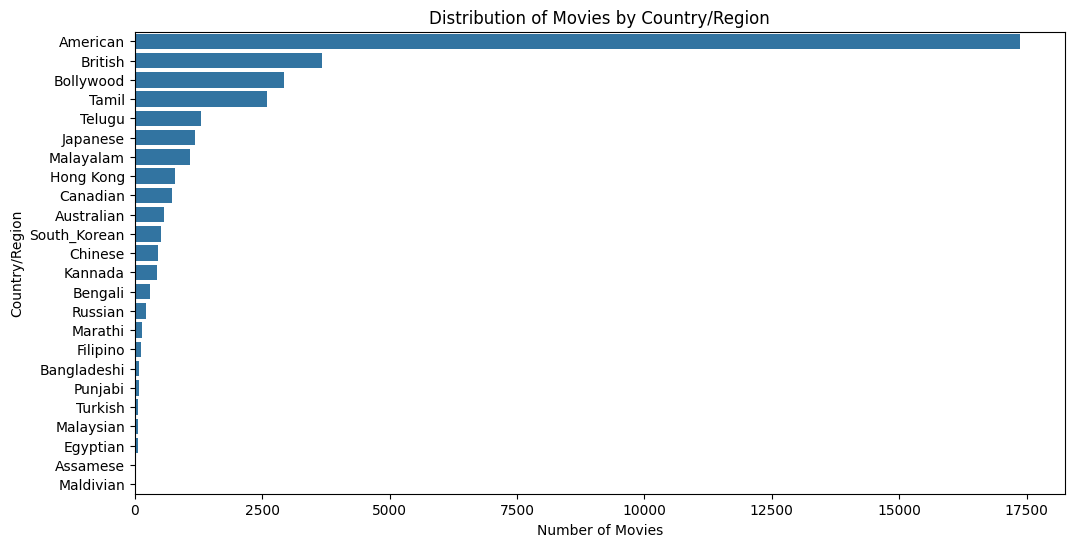

In [24]:
plt.figure(figsize=(12,6))
sns.countplot(y='Origin/Ethnicity', data=movie_plots_dataset, order=movie_plots_dataset['Origin/Ethnicity'].value_counts().index)
plt.title('Distribution of Movies by Country/Region')
plt.xlabel('Number of Movies')
plt.ylabel('Country/Region')
plt.show()

The most represented countries are USA, UK and India.

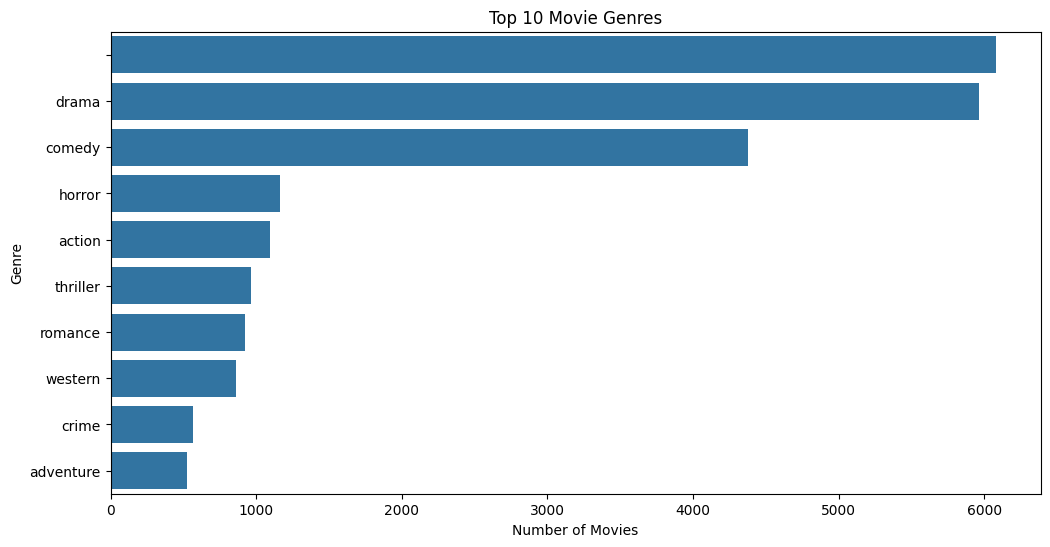

The most used genre is: 


In [ ]:
# Top 10 genres
plt.figure(figsize=(12,6))
sns.countplot(y='Genre', data=movie_plots_dataset, order=movie_plots_dataset['Genre'].value_counts().nlargest(10).index)
plt.title('Top 10 Movie Genres')
plt.xlabel('Number of Movies')
plt.ylabel('Genre')
plt.show()
most_used_genre = movie_plots_dataset['Genre'].value_counts().idxmax()
print(f"The most used genre is: {most_used_genre}") 

Ignoring 'unknown' genres, the most used genre is Drama, with Comedy and Horror following.

> Empty genred are not a problem for text enrichment as we will just concatenate an empty string.

We will split the dataset into training and testing sets, using 80% of the data for training and 20% for testing.

In [26]:
movie_plot_training_data, movie_plot_test_data = train_test_split(movie_plots_dataset, test_size=0.2, random_state=42)

### 1.3 Text Preprocessing

In [27]:
def clean_text(text):
    # to string
    text = str(text)
    
    # lower case
    text = text.lower()
    
    # remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # Remove parentheses and their content
    text = re.sub(r'\(.*?\)', '', text)

    # Remove special characters, numbers, punctuations (except for apostrophes)
    text = re.sub(r"[^a-zA-Z']", ' ', text)
    
    # remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Remove stop words (Stop words are common words that do not add much meaning to a sentence, such as "i", "me", "myself", etc.)
    stop_words = set(stopwords.words('english'))
    text_tokens = nltk.word_tokenize(text)
    filtered_words = [word for word in text_tokens if word not in stop_words]
    text = ' '.join(filtered_words)
    
    # Replace contractions
    contractions = {
        "ain't": "is not",
        "aren't": "are not",
        "can't": "cannot",
        "'cause": "because",
        "could've": "could have",
        "won't": "will not",
        "wouldn't": "would not",
        "didn't": "did not",
        "doesn't": "does not",
        "don't": "do not",
        "it's": "it is",
        "i'm": "I am",
        "they're": "they are",
        "we're": "we are",
        "you're": "you are",
        "that's": "that is",
        "there's": "there is",
        "what's": "what is",
        "who's": "who is",
        "couldn't": "could not",
        "shouldn't": "should not",
        "would've": "would have",
        "let's": "let us",
        "imma": "I am going to",
        "im": "I am",
        "Im": "I am",
        "n't": " not",
        "'re": " are",
        "'ve": " have",
        "'ll": " will",
        "'d": " would",
        "'s": " is",
        "'t": " not",
        "'m": " am",
    }
    for contraction, replacement in contractions.items():
        text = re.sub(r'\b' + re.escape(contraction) + r'\b', replacement, text, flags=re.IGNORECASE)

    return text

In [28]:
movie_plot_training_data['clean_text'] = movie_plot_training_data['Plot'].apply(clean_text)
movie_plot_test_data['clean_text'] = movie_plot_test_data['Plot'].apply(clean_text)

In [29]:
movie_plot_training_data.sample(1)

,Release Year,Title,Origin/Ethnicity,Director,Cast,Genre,Plot,clean_text
28550,2015,Adi Kapyare Kootamani,Malayalam,John Varghese,"Dhyan Sreenivasan, Aju Varghese, Namitha Pramod, and Neeraj Madhav",comedy,"The movie starts with the introduction of Father Alfred Kattuvilayil (Mukesh) who considers himself to be a very strict warden of a college boys hostel. His assistant Shaanthappan (Bijukuttan) always tries to show him the mischief of the students but always fails. Adhishta Lakshmi (Namitha Pramod) fights with her father (John Vijay) over her boyfriend and on the next day meets Bhanuprasad (Dhyan Sreenivasan) in the canteen of his college. Bhanu has lost his gold chain by lending it for his friend Harris (Bhagath Manuel). As he wanted money, Lakshmi offers the amount of rupees 20,000 for taking her to his hostel for some unknown reason on that night. That night Bhanu smuggles Lakshmi into the hostel, but by the time he tries to get her out, the way out was blocked. That night both stay in Bhanu's room. Not fully trusting Bhanu,Lakshmi ties Bhanu in his hostel room's study and sets alarm in his phone to be start at 3 AM. But both sleeps off as it is like a lullaby song and wake up only by eight, when Bhanu's friend Bruno (Aju Varghese) knocks his door. Bhanu skips college and tries to get her out. But the escape route was blocked by Father and Shanthappan. He tries to get her out through the Main entrance but to his horror, college was closed for strike as her father beaten an auto rickshaw driver because of him,dropped her in front of his hostel expecting that she (Adishta Lakshmi)escaped with his help. So the students came back to the hostel. Both stays in Bhanu's room for the whole day planning to escape from the terrace that night. When Bhanu goes to the terrace to check, he sees a number of students including his friends Bruno, Koshy (Vineeth Mohan) and Remo (Neeraj Madhav) boozing. They force him to drink and he forgets about Lakshmi locked in his room. When Shanthappan goes near Bhanu's room after sometime, he hears Lakshmi speaking in her sleep in Tamil. He thinks that it is a ghost and get the key from Bhanu's pocket and opens the door. Lakshmi kicks him and run out of the room, and Shanthappan is knocked out. Next day Bhanu wake up and Father is persuaded by Shanthappan to check Bhanu's room for the ghost. Bhanu opens the room reluctantly and is surprised not to see Lakshmi. He then finds out that his friends found out about Lakshmi and they together plans to get her out. Bhanu meets Lakshmi in Bruno's room. Lakshmi tells them the reason that she came in the hostel. She had a lover Premraj (Roshan Mathew)who was a Casanova, who was in the hostel, and after he broke up with her she wanted to take revenge. So she went to his room and slapped him. Friends while planning to get her out, is irritated by the behavior of Remo as he constantly tries to flirt with Lakshmi. That day night when they try to get her out from the terrace, Father and Shanthappan see her in white dress and both believes that there is a ghost. Then Bhanu makes a new plan: to make everyone believe that there is actually a ghost and he will summon her with Ouija board in the presence of Father. When Father do some magical rituals the Ghost (Lakshmi) will leave and that way she can get out of the hostel. They plan and does things so that other inmates believe that there is a ghost. But in reality, there was an actual ghost in the hostel who came when Bhanu used the Ouija board. But Lakshmi successfully gets out of the hostel as per the original plan, even though some super natural events occur. The ghost is shown still wandering through the hostel.\r\nIn the credits, Lakshmi is in her house and Bhanu visits her with her bag which she had forgotten in his room. She asks him to leave but hears her fathers voice and asks him to wait till three in the morning. Bhanu now understands that he is trapped in her house just like how she was trapped in the hostel

> Plot texts have mentions of the actors names between parentheses, we will remove them as they do not add relevant information to the plot description.

In [35]:
print(movie_plot_training_data.clean_text.apply(type).value_counts())
print(movie_plot_training_data.clean_text[movie_plot_training_data.clean_text.apply(lambda x: isinstance(x, float))])
movie_plot_training_data = movie_plot_training_data.dropna(subset=['clean_text'])
movie_plot_training_data['clean_text'] = movie_plot_training_data['clean_text'].astype(str)
print(movie_plot_test_data.clean_text.apply(type).value_counts())
print(movie_plot_test_data.clean_text[movie_plot_test_data.clean_text.apply(lambda x: isinstance(x, float))])
movie_plot_test_data = movie_plot_test_data.dropna(subset=['clean_text'])
movie_plot_test_data['clean_text'] = movie_plot_test_data['clean_text'].astype(str)

clean_text
<class 'str'>      27907
<class 'float'>        1
Name: count, dtype: int64
22837    NaN
Name: clean_text, dtype: object
clean_text
<class 'str'>    6978
Name: count, dtype: int64
Series([], Name: clean_text, dtype: object)


In [31]:
movie_plot_training_data.to_csv('datasets/movie_plot_training_data.csv', index=False)
movie_plot_test_data.to_csv('datasets/movie_plot_test_data.csv', index=False)

In [32]:
movie_plot_training_data = pd.read_csv('datasets/movie_plot_training_data.csv')
movie_plot_test_data = pd.read_csv('datasets/movie_plot_test_data.csv')

### 1.4 Word Embeddings and Similarity Computation

We will use Word2Vec as the word embedding technique for representing the movie plots. Word2Vec is effective in capturing semantic relationships between words, which is crucial for understanding the context of movie plots.

A vector size of 300 dimensions will be used, as it provides a good balance between capturing semantic information and computational efficiency. The window size will be set to 5, allowing the model to consider a reasonable context around each word. A minimum word count of 2 will be used to filter out infrequent words that may not contribute significantly to the embeddings.

In [36]:
texts = movie_plot_training_data['clean_text'].apply(preprocess_string).tolist()
word2vec_movie_plot_model = Word2Vec(sentences=texts, vector_size=300, window=5, min_count=2, workers=1)
word2vec_movie_plot_model.save("models/word2vec_movie_plot_model.model")

Let's test the embedding quality

In [37]:
word_vectors = word2vec_movie_plot_model.wv
similarity = word_vectors.similarity('horror', 'monster')
print(f"Similarity between 'horror' and 'monster': {similarity}")

# similarity = word_vectors.similarity('comedy', 'funny')
# print(f"Similarity between 'comedy' and 'funny': {similarity}")

# similarity = word_vectors.similarity('action', 'adventure')
# print(f"Similarity between 'action' and 'adventure': {similarity}")

# similarity = word_vectors.similarity('romance', 'love')
# print(f"Similarity between 'romance' and 'love': {similarity}")

Similarity between 'horror' and 'monster': 0.4994235336780548


Horror and monster have a similarity of 0.5 which is reasonable but not very high. This could be due to the fact that while they are related concepts, they are not synonymous. Other pairs tried returned errors due to words not being in the vocabulary, this could be solved by enriching the training data with other columns.

> For movie recommendation, we don’t care about word-word similarity. You care about movie-movie similarity,

### 1.5 Calculate Movie Embeddings
Now that we have a trained Word2Vec model, we can compute the embeddings for each movie by averaging the word vectors of all words in the movie's plot description. This will give us a fixed-size vector representation for each movie.

In [38]:
def movie_vector(tokens, model):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(model.vector_size)

movie_vectors = np.array([movie_vector(text, word2vec_movie_plot_model)
                          for text in texts])

Then we build the recommendation system based on cosine similarity

In [39]:
from sklearn.metrics.pairwise import cosine_similarity
similarity_matrix = cosine_similarity(movie_vectors)


And finally we can test the recommendation system

In [40]:
def recommend_movies(movie_index, similarity_matrix, movie_titles, top_n=5):
    similarity_scores = list(enumerate(similarity_matrix[movie_index]))
    similarity_scores = sorted(similarity_scores, key=lambda x: x[1], reverse=True)
    similarity_scores = similarity_scores[1:top_n+1]
    recommended_movie_indices = [i[0] for i in similarity_scores]
    recommended_movies = movie_titles.iloc[recommended_movie_indices]
    return recommended_movies

movie_titles = movie_plot_training_data['Title']
movie_index = 0  # Index of the movie for which we want recommendations
recommended_movies = recommend_movies(movie_index, similarity_matrix, movie_titles, top_n=5)
print(f"Movies similar to '{movie_titles.iloc[movie_index]}':")
for i, title in enumerate(recommended_movies, start=1):
    print(f"{i}. {title}")

Movies similar to 'Care Bears !The Care Bears' Big Wish Movie':
1. The Care Bears Movie
2. Care Bears: Journey to Joke-a-lot
3. Eiga Tamagotchi: Himitsu no Otodake Daisakusen!
4. Crayon Shin-chan: Fast Asleep! The Great Assault on Dreamy World!
5. Care Bears Movie II: A New Generation


In [41]:
def ask_movies(movie_name, similarity_matrix, movie_titles, top_n=5):
    try:
        movie_index = movie_titles[movie_titles == movie_name].index[0]
    except IndexError:
        print(f"Movie '{movie_name}' not found in the dataset.")
        return []
    
    similarity_scores = list(enumerate(similarity_matrix[movie_index]))
    similarity_scores = sorted(similarity_scores, key=lambda x: x[1], reverse=True)
    similarity_scores = similarity_scores[1:top_n+1]
    recommended_movie_indices = [i[0] for i in similarity_scores]
    recommended_movies = movie_titles.iloc[recommended_movie_indices]
    return recommended_movies

In [42]:
ask_movies("The Lord of the Rings", similarity_matrix, movie_titles, top_n=5)

14244                          The Lord of the Rings: The Fellowship of the Ring
11264                                      The Lord of the Rings: The Two Towers
13943                                                     The Return of the King
22458    Hobbit: The Desolation of Smaug, TheThe Hobbit: The Desolation of Smaug
23623                                              Kingsglaive: Final Fantasy XV
Name: Title, dtype: object

### 1.6 Review

- We could have selected only movies from USA and UK to reduce variability.
- Also, we could have used TF-IDF weighting when averaging the word vectors to give more importance to significant words in the plot descriptions. And see if that improves recommendations.
- We didn't try enriching the text with other columns, which could have improved the quality of the embeddings and recommendations.
- When doing the preprocessing, we could have used lemmatization or stemming to reduce words to their base forms, which can help in capturing the core meaning of the text.

> Preprocessing rules really depends on the dataset and the problem at hand.

#### 1.6.1 Preprocessing with more advanced techniques

In [73]:
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text_v2(text):
    # to string
    text = str(text)
    
    # lower case
    text = text.lower()
    
    # remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # Remove special characters, numbers, punctuations (except for apostrophes)
    text = re.sub(r"[^a-zA-Z']", ' ', text)
    
    # remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    VERB_CODES = ['VB', 'VBD', 'VBG', 'VBN', 'VBP', 'VBZ']

    temp_sentence = []
    words = nltk.word_tokenize(text)
    tags = nltk.pos_tag(words)
    for i, word in enumerate(words):
        if tags[i][1] in VERB_CODES:
            lemmatized = lemmatizer.lemmatize(word, 'v')
        else:
            lemmatized = lemmatizer.lemmatize(word)
        if word not in stop_words and lemmatized.isalpha():
            temp_sentence.append(lemmatized)
    text = ' '.join(temp_sentence)

    text = text.replace("n't", " not")
    text = text.replace("'re", " are")
    text = text.replace("'ve", " have")
    text = text.replace("'ll", " will")
    text = text.replace("'d", " would")
    text = text.replace("'s", " is")
    text = text.replace("'t", " not")
    text = text.replace("'m", " am")
            
    return text

movie_plot_training_data['clean_text_v2'] = movie_plot_training_data['Plot'].apply(clean_text_v2)
movie_plot_test_data['clean_text_v2'] = movie_plot_test_data['Plot'].apply(clean_text_v2)

movie_plot_training_data.head(1)

,Release Year,Title,Origin/Ethnicity,Director,Cast,Genre,Plot,clean_text,clean_text_v2
0,2005,Care Bears !The Care Bears' Big Wish Movie,Canadian,Larry Jacobs & Ron Pitts,"voices Stephanie Beard, Robert Tinkler, Julie Lemieux, Linda Ballantyne, Stephen Ouimette",animated feature,"This movie starts when, atop the roof of an observatory at their cloud-filled home of Care-a-lot, the Care Bears hear Wish Bear's story of how she (as a Cub) found her new friend, a wishing star named Twinkers. The Care Bears are touched by this tale, but are a bit worried when she uses Twinkers' inherent power to wish them all some popcorn. Cheer Bear raises concern that this may be a frivolous use of Twinkers' power. Wish Bear, however, assures everyone that she is a trained professional.\r\nThe next day, Wish Bear uses the wishing power to help her friends. She wishes for plenty of rainbow sap for Share Bear, and for Grumpy Bear's rocket to have ""zoom"", but the wishes backfire when the sap overflows and the rocket spins out of control.\r\nA monthly meeting of Care-a-lot's steering committee (with Champ Bear presiding) reveals a problem with the Caring Meter. The machine, which measures how much caring there is in Care-a-lot, has moved towards the raincloud side. Wish Bear suggests using her wishes, but is rejected since not all of them work as intended; they didn't like their wishes (""I Wish""). Disappointed, she decides to wish for other bears who like wishing as much as she does. This causes three new bears to arrive in Care-a-lot: Me Bear, Messy Bear, and Too Loud Bear.\r\nEveryone is pleased to welcome the new neighbours at first, but things soon get out of control. The new bears unwittingly make a huge mess of everything (especially when the huge mansion they asked for causes pollution). Then, after a confrontation with them at a picnic (""Get a Lot"") Wish Bear accidentally wishes Twinkers away to the new bears; they soon abuse the star's power with an amusement park focusing on Me Bear, a mud pie for Messy Bear, and a huge noisy motorcycle for Too Loud Bear. Once the new bears finally realise their problem, they try to fix it with more wishes, but to no avail—Care-a-lot becomes a blank white space (wishing that all of this was gone), the bears begin to glow in color (wishing for everything to be back how it was, but with more color), Grumpy Bear turns black and white (wishing for less color), and Messy Bear turns into Messy Cub (wishing for everything to be like it used to be). When they try to wish Twinkers back to Wish Bear, the star ultimately loses his power from exhaustion (because they had been pushing him much too hard). Wish Bear uses Grumpy Bear's rocket to bring him to the Big Wish, a grandmother star, in the sky. Big Wish restores his power, but not before Wish Bear assures her that she has learned her lesson, which is wishing is fun, but it is far more important to work hard to achieve your dreams.\r\nWish Bear tells them that wishes are not an effective solution any more, and everyone works together to make their home beautiful again (""It Takes You and Me""). At the end, Me Bear, Messy Bear, and Too Loud Bear, having seen the error of their ways, apologize and ask if they can still live in Care-a-lot. The rest of the bears agree and decide to go on a road trip.",movie starts atop roof observatory cloud filled home care lot care bears hear wish bear 's story found new friend wishing star named twinkers care bears touched tale bit worried uses twinkers ' inherent power wish popcorn cheer bear raises concern may frivolous use twinkers ' power wish bear however assures everyone trained professional next day wish bear uses wishing power help friends wishes plenty rainbow sap share bear grumpy bear 's rocket zoom wishes backfire sap overflows rocket spins control monthly meeting care lot 's steering committee reveals problem caring meter machine measures much caring care lot moved towards raincloud side wish bear suggests using wi

In [74]:
print(movie_plot_training_data.clean_text_v2.apply(type).value_counts())
print(movie_plot_training_data.clean_text_v2[movie_plot_training_data.clean_text_v2.apply(lambda x: isinstance(x, float))])
movie_plot_training_data = movie_plot_training_data.dropna(subset=['clean_text_v2'])
movie_plot_training_data['clean_text_v2'] = movie_plot_training_data['clean_text_v2'].astype(str)
print(movie_plot_test_data.clean_text_v2.apply(type).value_counts())
print(movie_plot_test_data.clean_text_v2[movie_plot_test_data.clean_text_v2.apply(lambda x: isinstance(x, float))])
movie_plot_test_data = movie_plot_test_data.dropna(subset=['clean_text_v2'])
movie_plot_test_data['clean_text_v2'] = movie_plot_test_data['clean_text_v2'].astype(str)

clean_text_v2
<class 'str'>    27907
Name: count, dtype: int64
Series([], Name: clean_text_v2, dtype: object)
clean_text_v2
<class 'str'>    6978
Name: count, dtype: int64
Series([], Name: clean_text_v2, dtype: object)


In [75]:
movie_plot_training_data.to_csv('datasets/movie_plot_training_data_v2.csv', index=False)
movie_plot_test_data.to_csv('datasets/movie_plot_test_data_v2.csv', index=False)

In [76]:
movie_plot_training_data = pd.read_csv('datasets/movie_plot_training_data_v2.csv')
movie_plot_test_data = pd.read_csv('datasets/movie_plot_test_data_v2.csv')

In [77]:
texts = movie_plot_training_data['clean_text_v2'].apply(preprocess_string).tolist()
word2vec_movie_plot_model = Word2Vec(sentences=texts, vector_size=300, window=5, min_count=2, workers=1)
word2vec_movie_plot_model.save("models/word2vec_movie_plot_model_v2.model")

In [80]:
word_vectors = word2vec_movie_plot_model.wv
similarity = word_vectors.similarity('horror', 'monster')
print(f"Similarity between 'horror' and 'monster': {similarity}")

# similarity = word_vectors.similarity('comedy', 'funny')
# print(f"Similarity between 'comedy' and 'funny': {similarity}")

# similarity = word_vectors.similarity('action', 'adventure')
# print(f"Similarity between 'action' and 'adventure': {similarity}")

# similarity = word_vectors.similarity('romance', 'love')
# print(f"Similarity between 'romance' and 'love': {similarity}")

Similarity between 'horror' and 'monster': 0.5052930116653442


In [81]:
def movie_vector(tokens, model):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(model.vector_size)

movie_vectors = np.array([movie_vector(text, word2vec_movie_plot_model)
                          for text in texts])

In [82]:
from sklearn.metrics.pairwise import cosine_similarity
similarity_matrix = cosine_similarity(movie_vectors)


In [84]:
def recommend_movies(movie_index, similarity_matrix, movie_titles, top_n=5):
    similarity_scores = list(enumerate(similarity_matrix[movie_index]))
    similarity_scores = sorted(similarity_scores, key=lambda x: x[1], reverse=True)
    similarity_scores = similarity_scores[1:top_n+1]
    recommended_movie_indices = [i[0] for i in similarity_scores]
    recommended_movies = movie_titles.iloc[recommended_movie_indices]
    return recommended_movies

movie_titles = movie_plot_training_data['Title']
movie_index = 0  # Index of the movie for which we want recommendations
recommended_movies = recommend_movies(movie_index, similarity_matrix, movie_titles, top_n=5)
print(f"Movies similar to '{movie_titles.iloc[movie_index]}':")
for i, title in enumerate(recommended_movies, start=1):
    print(f"{i}. {title}")

Movies similar to 'Care Bears !The Care Bears' Big Wish Movie':
1. Care Bears: Journey to Joke-a-lot
2. The Care Bears Movie
3. Crayon Shin-chan: Fast Asleep! The Great Assault on Dreamy World!
4. A Bear For Punishment
5. Blizzard


In [83]:
def ask_movies(movie_name, similarity_matrix, movie_titles, top_n=5):
    try:
        movie_index = movie_titles[movie_titles == movie_name].index[0]
    except IndexError:
        print(f"Movie '{movie_name}' not found in the dataset.")
        return []
    
    similarity_scores = list(enumerate(similarity_matrix[movie_index]))
    similarity_scores = sorted(similarity_scores, key=lambda x: x[1], reverse=True)
    similarity_scores = similarity_scores[1:top_n+1]
    recommended_movie_indices = [i[0] for i in similarity_scores]
    recommended_movies = movie_titles.iloc[recommended_movie_indices]
    return recommended_movies

ask_movies("The Lord of the Rings", similarity_matrix, movie_titles, top_n=5)

14244                          The Lord of the Rings: The Fellowship of the Ring
11264                                      The Lord of the Rings: The Two Towers
13943                                                     The Return of the King
22458    Hobbit: The Desolation of Smaug, TheThe Hobbit: The Desolation of Smaug
24922                                                    Jason and the Argonauts
Name: Title, dtype: object

We see that the recommendations are a bit different from the previous model, but still relevant.

In [88]:
ask_movies("Harry Potter and the Chamber of Secrets", similarity_matrix, movie_titles, top_n=5)

4429            Harry Potter and the Sorcerer's Stone
19738    Harry Potter and the Deathly Hallows: Part I
25121    Harry Potter and the Deathly Hallows: Part 1
11033          Harry Potter and the Half-Blood Prince
12725    Harry Potter and the Deathly Hallows: Part 2
Name: Title, dtype: object

> We can see also that same movies are duplicated in the recommendations, this would be something to keep improving, same with trying better preprocessing techniques.

#### 1.6.2 Using TFIDF weighted Word2Vec embeddings

TF-IDF weighting helps to emphasize important words in the plot descriptions while down-weighting common words that may not contribute significantly to the meaning. This can lead to more accurate movie embeddings and potentially better recommendations.
> Common words like "the", "is", "and" will have lower weights, while unique words that are more descriptive of the movie's plot will have higher weights.

In [85]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidvec = TfidfVectorizer()
tfidf_movieid = tfidvec.fit_transform(movie_plot_training_data['clean_text_v2'])

In [86]:
from sklearn.metrics.pairwise import cosine_similarity
similarity_matrix = cosine_similarity(tfidf_movieid)

In [87]:
ask_movies("The Lord of the Rings", similarity_matrix, movie_titles, top_n=5)

14244                          The Lord of the Rings: The Fellowship of the Ring
13943                                                     The Return of the King
11264                                      The Lord of the Rings: The Two Towers
22458    Hobbit: The Desolation of Smaug, TheThe Hobbit: The Desolation of Smaug
9814                                                                   Maa Kasam
Name: Title, dtype: object

The recommendations are similar to the models using Word2Vec embeddings, but there are some differences in the order and selection of recommended movies. One recommendation here "Maa Kasam" seems less relevant compared to the previous models. Not surprising as TF-IDF can sometimes overemphasize rare words that may not be contextually important, while Word2Vec captures semantic relationships better.

## 2. Sentiment analysis of film reviews

### 2.1 Loading the dataset

In [43]:
import opendatasets as od
import pandas as pd
pd.set_option('display.max_colwidth', None)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud
import re
import gensim.downloader
from gensim.models import Word2Vec
from gensim.parsing.preprocessing import preprocess_string
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Dense, Dropout, Embedding, Flatten, LSTM
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from transformers import BertTokenizer, TFBertModel
from sklearn.model_selection import train_test_split
from scipy.special import softmax

# uv run python -m spacy download en_core_web_sm
nlp = spacy.load("en_core_web_sm")
nltk.download('vader_lexicon')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /home/javier/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package stopwords to /home/javier/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/javier/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /home/javier/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/javier/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [103]:
movie_reviews_dataset = pd.read_csv('datasets/IMDB Dataset.csv')
movie_reviews_dataset.head()

,review,sentiment
0,"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fact that it goes where other shows wouldn't dare. Forget pretty pictures painted for mainstream audiences, forget charm, forget romance...OZ doesn't mess around. The first episode I ever saw struck me as so nasty it was surreal, I couldn't say I was ready for it, but as I watched more, I developed a taste for Oz, and got accustomed to the high levels of graphic violence. Not just violence, but injustice (crooked guards who'll be sold out for a nickel, inmates who'll kill on order and get away with it, well mannered, middle class inmates being turned into prison bitches due to their lack of street skills or prison experience) Watching Oz, you may become comfortable with what is uncomfortable viewing....thats if you can get in touch with your darker side.",positive
1,"A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. <br /><br />The actors are extremely well chosen- Michael Sheen not only ""has got all the polari"" but he has all the voices down pat too! You can truly see the seamless editing guided by the references to Williams' diary entries, not only is it well worth the watching but it is a terrificly written and performed piece. A masterful production about one of the great master's of comedy and his life. <br /><br />The realism really comes home with the little things: the fantasy of the guard which, rather than use the traditional 'dream' techniques remains solid then disappears. It plays on our knowledge and our senses, particularly with the scenes concerning Orton and Halliwell and the sets (particularly of their flat with Halliwell's murals decorating every surface) are terribly well done.",positive
2,"I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned theater and watching a light-hearted comedy. The plot is simplistic, but the dialogue is witty and the characters are likable (even the well bread suspected serial killer). While some may be disappointed when they realize this is not Match Point 2: Risk Addiction, I thought it was proof that Woody Allen is still fully in control of the style many of us have grown to love.<br /><br />This was the most I'd laughed at one of Woody's comedies in years (dare I say a decade?). While I've never been impressed with Scarlet Johanson, in this she managed to tone down her ""sexy"" image and jumped right into a average, but spirited young woman.<br /><br />This may not be the crown jewel of his career, but it was wittier than ""Devil Wears Prada"" and more interesting than ""Superman"" a great comedy to go see with friends.",positive
3,"Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />This movie is slower than a soap opera... and suddenly, Jake decides to become Rambo and kill the zom

### 2.2 Analysis of the dataset and Cleaning

In [104]:
print(f"dataset size: {movie_reviews_dataset.shape}")
print(movie_reviews_dataset.columns)
print("Null values per column:")
print(movie_reviews_dataset.isnull().sum())
print("Sentiment value counts:")
print(movie_reviews_dataset['sentiment'].value_counts())
print(f"Number of unknown reviews: {(movie_reviews_dataset['review'] == 'unknown').sum()}")
print(f"Number of empty reviews: {(movie_reviews_dataset['review'].str.strip() == '').sum()}")

dataset size: (50000, 2)
Index(['review', 'sentiment'], dtype='object')
Null values per column:
review       0
sentiment    0
dtype: int64
Sentiment value counts:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64
Number of unknown reviews: 0
Number of empty reviews: 0


- We have two columns: 'review' and 'sentiment'.
- The 'review' column contains the text of the movie review, while the 'sentiment' column indicates whether the review is positive or negative. 
- The dataset contains 50,000 reviews, with an equal distribution of positive and negative sentiments (25,000 each), making it a balanced dataset.
- There are no null values in either column.
- There are no unknown or empty reviews.

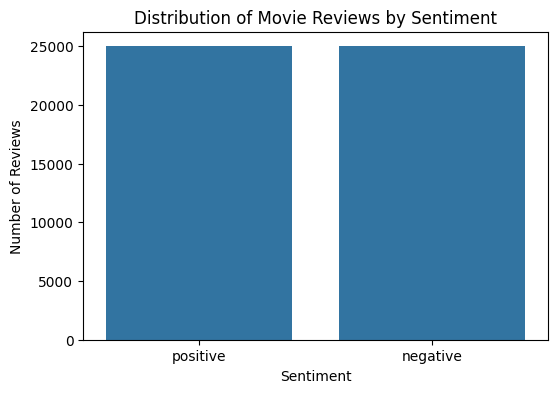

In [46]:
plt.figure(figsize=(6,4))
sns.countplot(x='sentiment', data=movie_reviews_dataset)
plt.title('Distribution of Movie Reviews by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()

### 2.3 Preprocessing the data

We will preprocess the data to prepare it for training. This includes removing stop words, punctuation, special characters, and others.

In [ ]:
def clean_review(text):
    # to string
    text = str(text)
    
    # lower case
    text = text.lower()
    
    # remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # Remove html tags
    text = re.sub(r'<.*?>', '', text)

    # Remove special characters, numbers, punctuations (except for apostrophes)
    text = re.sub(r"[^a-zA-Z']", ' ', text)
    
    # remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    
    # Replace contractions
    contractions = {
        "ain't": "is not",
        "aren't": "are not",
        "can't": "cannot",
        "'cause": "because",
        "could've": "could have",
        "won't": "will not",
        "wouldn't": "would not",
        "didn't": "did not",
        "doesn't": "does not",
        "don't": "do not",
        "it's": "it is",
        "i'm": "I am",
        "they're": "they are",
        "we're": "we are",
        "you're": "you are",
        "that's": "that is",
        "there's": "there is",
        "what's": "what is",
        "who's": "who is",
        "couldn't": "could not",
        "shouldn't": "should not",
        "would've": "would have",
        "let's": "let us",
        "imma": "I am going to",
        "im": "I am",
        "Im": "I am",
        "n't": " not",
        "'re": " are",
        "'ve": " have",
        "'ll": " will",
        "'d": " would",
        "'s": " is",
        "'t": " not",
        "'m": " am",
    }
    for contraction, replacement in contractions.items():
        text = re.sub(r'\b' + re.escape(contraction) + r'\b', replacement, text, flags=re.IGNORECASE)

    # Remove stop words (Stop words are common words that do not add much meaning to a sentence, such as "i", "me", "myself", etc.)
    stop_words = set(stopwords.words('english'))
    text_tokens = nltk.word_tokenize(text)
    filtered_words = [word for word in text_tokens if word not in stop_words]
    text = ' '.join(filtered_words)
    
    return text

In [106]:
training_data, test_data = train_test_split(movie_reviews_dataset, test_size=0.2, random_state=42)
training_data['clean_review'] = training_data['review'].apply(clean_review)
test_data['clean_review'] = test_data['review'].apply(clean_review)
training_data['clean_review'] = training_data['clean_review'].astype(str)
test_data['clean_review'] = test_data['clean_review'].astype(str)

In [107]:
training_data.sample(5)

review  \
17139                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       I just came back from the Late-night cinema and it was indeed a silent way out as most of the audience pondered though the real-life black & white images of the partition,the freedom movement,etc which was very much reminiscent of the lives' our forefathers faced! Amidst this backdrop,mind you,there was no tel/fax/internet in those times but for the very voice of Truth & Non-violence, the cinematography infused some spirit of stark reality of adversity amidst the strict Raj.<br /><br />Gandhi shown as a hardworking Attorney in South Africa,who stood for his basic ideologies and gave every degree of conviction to spread awareness of the same with humility and sainthood which to the uttered speech of general Smut was shown as a nice farewell on screen.It had the best drafted speech with a subtle humour & a veiled threat to the British raj in India!There was a nice remark when he said we pray in silence to the British in India now that Gandhi,the politician is set for India(towards sainthood).<br /><br />The very backdrop of a big family with many kids needs the mention of an obvious divided attention and love which had to cast it's spell on the unfortunate kid's psyche who was left alone to aspire for unrealistic ambitions.Little did Harilal knew about his aptitude and he gets emotionally carried away with small pleasures in life and fails in front of the huge idol of his father.He tries to do away from mentor-ship which is the basis of any success which had to be seen by those fortunate neighbours in the streets of Gandhi's residence when Harilal vents out his frustration in open.This means he becomes mentally weak and gets psychologically deranged to an extent that he is forced into religious conversions and alcoholism ,with debt and dis-obedience fuelling his negative thoughts.He still had shown the sincere love for his mother through touchy scenes and even Gandhi's humble expressions form Harilal to forgive him didn't meet any conclusions in his mind as he always feared the Father,Gandhi.<br /><br />he couldn't digest the fact that Gandhi couldn't share his love with him as he expected & was driven to rebellion when he couldn't understand the equal-merit based delivery of scholarship money by his father to his cousin where he saw a failed opportunity to study for barrister in england.<br /><br />This had to take it's toll in him thrown to the streets as a beggar when the whole of India was celebrating the Indepedence!The life of a destitute never changes come what may but the manner in which the sad death of Kasturba & Gandhi himself is shown brings in an emotional silence.Finally the last turbulent thoughts of the dying Harilal is shown as a flashback to keep the audience gripping and wondering where did the father of the nation go wrong? was he clever enough to be mentally strong to lead an-one man army & use his brave soldier-son as a weapon to show to the British & rival forces that when it comes to the interest of the nation,nothing comes in between.Sadly though that to read a Mahatma's heart one has to live outside his family and see which the emotionally naive harilal couldn't see living inside....<br /><br />A pity that such naive harilal's are still ruining the efforts of many Mahatma-like fathers in many families in todays' life and h

In [108]:
training_data.to_csv('datasets/movie_review_training_data.csv', index=False)
test_data.to_csv('datasets/movie_review_test_data.csv', index=False)
training_data = pd.read_csv('datasets/movie_review_training_data.csv')
test_data = pd.read_csv('datasets/movie_review_test_data.csv')

### 2.4 Wordcloud of positive and negative reviews

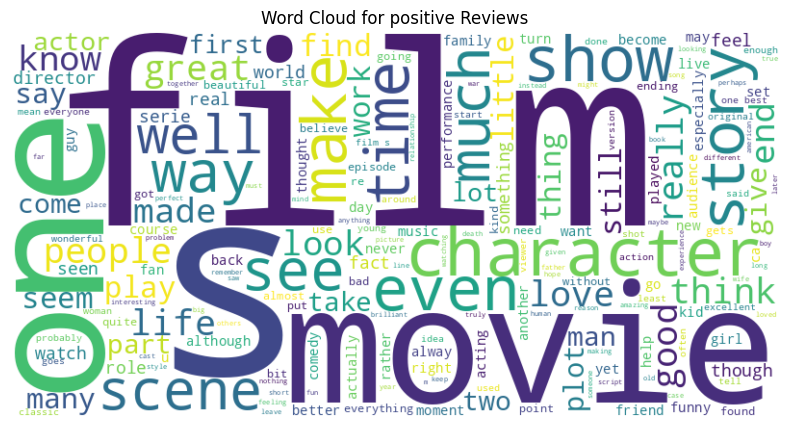

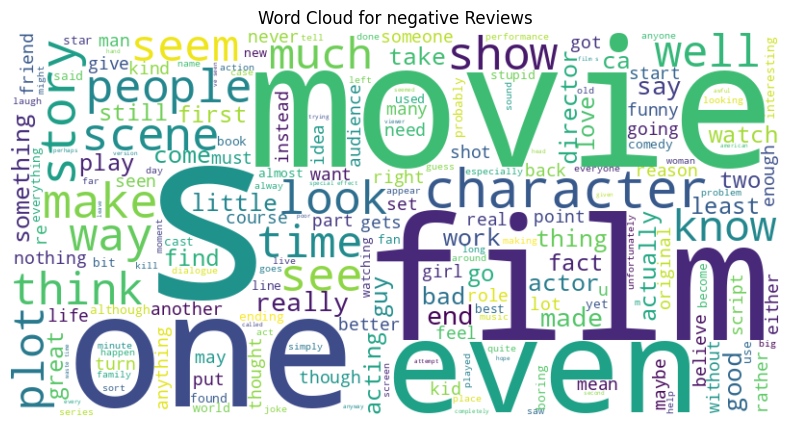

In [54]:
for sentiment in ['positive', 'negative']:
    plt.figure(figsize=(10,5))
    text = ' '.join(training_data[training_data['sentiment'] == sentiment]['clean_review'])
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f'Word Cloud for {sentiment} Reviews')
    plt.axis('off')
    plt.show()

Cloudwords for positive and negative reviews show distinct patterns in word usage. Positive reviews frequently use words like "really", "great", "well", "made", "love". Negative reviews is more diffuse. Overall the reviews are so diverse that it is difficult to find clear patterns.

### 2.5 Word Embeddings

In [55]:
reviews = training_data['clean_review'].apply(preprocess_string).tolist()
word2vec_movie_review_model = Word2Vec(sentences=reviews, vector_size=300, window=5, min_count=2, workers=1)
word2vec_movie_review_model.save("models/word2vec_movie_review_model.model")

### 2.6 Sentiment Analysis Model Architecture

We will build a sentiment analysis model using a Bidirectional LSTM architecture. This architecture is well-suited for text classification tasks as it can capture dependencies in both directions (past and future context) in the text data. We will use pre-trained Word2Vec embeddings to initialize the embedding layer, which will help the model leverage semantic information from a larger corpus.

In [60]:
training_data['sentiment'] = training_data['sentiment'].map({'positive': 1, 'negative': 0})

y = training_data['sentiment'].values

We start by mapping the sentiment labels to binary values and extracting the target variable.

To use Word2Vec embeddings, we will create an embedding matrix where each row corresponds to a word in our vocabulary, and the columns represent the embedding dimensions. We will initialize this matrix with the pre-trained Word2Vec vectors. We also need to use a tokenizer to convert the text reviews into sequences of word indices that correspond to the rows in the embedding matrix. And padding the sequences to ensure they are of uniform length, because LSTM networks require fixed-size input.

In [61]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(training_data['clean_review'].values)
X = tokenizer.texts_to_sequences(training_data['clean_review'].values)
X = pad_sequences(X, maxlen=500)

In [62]:
embedding_matrix = np.zeros((len(tokenizer.word_index) + 1, 300))
word_vectors = word2vec_movie_review_model.wv
for word, i in tokenizer.word_index.items():
    if word in word_vectors:
        embedding_matrix[i] = word_vectors[word]

embedding_matrix.shape

(96599, 300)

In [63]:
model_lstm = Sequential()
model_lstm.add(Embedding(input_dim=len(tokenizer.word_index) + 1, weights=[embedding_matrix], output_dim=300, input_length=500, trainable=False))
model_lstm.add(LSTM(units=128))
model_lstm.add(Dense(1, activation='sigmoid'))

model_lstm.summary()

/home/javier/Documents/IA/IA learning/lab5/.venv/lib/python3.13/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │    28,979,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,979,700 (110.55 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 28,979,700 (110.55 MB)

In [64]:
model_lstm.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
history_lstm = model_lstm.fit(X, y, epochs=5, validation_split=0.2)

Epoch 1/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 294s 292ms/step - accuracy: 0.7603 - loss: 0.5083 - val_accuracy: 0.7990 - val_loss: 0.4421
Epoch 2/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 295s 295ms/step - accuracy: 0.8097 - loss: 0.4254 - val_accuracy: 0.8151 - val_loss: 0.4135
Epoch 3/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 295s 295ms/step - accuracy: 0.8204 - loss: 0.4005 - val_accuracy: 0.8175 - val_loss: 0.4078
Epoch 4/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 300s 300ms/step - accuracy: 0.8352 - loss: 0.3733 - val_accuracy: 0.8250 - val_loss: 0.3934
Epoch 5/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 243s 243ms/step - accuracy: 0.8483 - loss: 0.3510 - val_accuracy: 0.8177 - val_loss: 0.4100


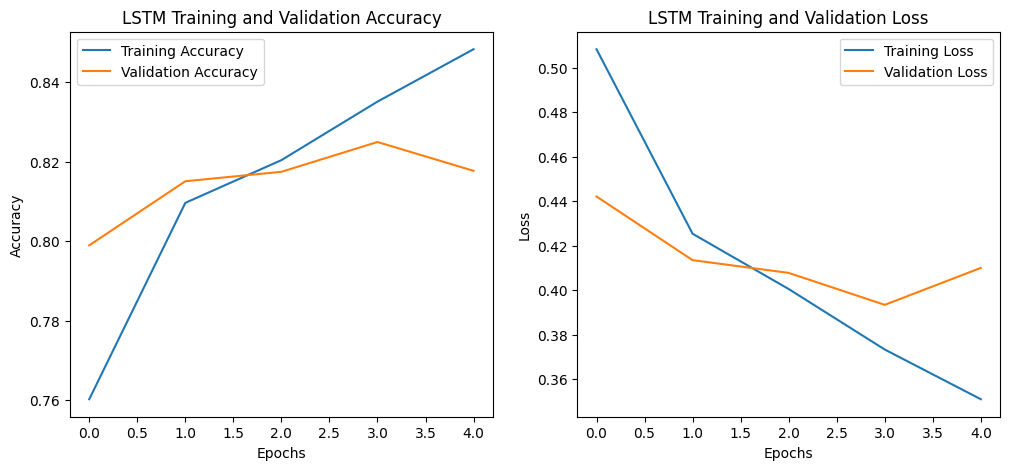

In [65]:
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.plot(history_lstm.history['accuracy'], label='Training Accuracy')
plt.plot(history_lstm.history['val_accuracy'], label='Validation Accuracy')
plt.title('LSTM Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_lstm.history['loss'], label='Training Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')
plt.title('LSTM Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [66]:
def make_predictions_lstm(text):
    preprocessed_text = clean_review(text)
    sequence = tokenizer.texts_to_sequences([preprocessed_text])
    padded_sequence = pad_sequences(sequence, maxlen=100)
    prediction = model_lstm.predict(padded_sequence)
    sentiment = 'Positive' if prediction[0][0] >= 0.5 else 'Negative'
    return sentiment, prediction[0][0]

In [67]:
example_review = "I absolutely loved this movie! The plot was thrilling and the characters were so well developed."
sentiment, confidence = make_predictions_lstm(example_review)
print(f"Review: {example_review}")
print(f"Predicted Sentiment: {sentiment} (Confidence: {confidence:.4f})")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
Review: I absolutely loved this movie! The plot was thrilling and the characters were so well developed.
Predicted Sentiment: Positive (Confidence: 0.7419)


In [69]:
example_review = "This was the worst movie I have ever seen. The plot made no sense and the acting was terrible."
sentiment, confidence = make_predictions_lstm(example_review)
print(f"Review: {example_review}")
print(f"Predicted Sentiment: {sentiment} (Confidence: {confidence:.4f})")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Review: This was the worst movie I have ever seen. The plot made no sense and the acting was terrible.
Predicted Sentiment: Negative (Confidence: 0.0118)


In [68]:
example_review = "I absolutely loved how terrible this movie was. The plot made no sense and the characters were so poorly developed."
sentiment, confidence = make_predictions_lstm(example_review)
print(f"Review: {example_review}")
print(f"Predicted Sentiment: {sentiment} (Confidence: {confidence:.4f})")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Review: I absolutely loved how terrible this movie was. The plot made no sense and the characters were so poorly developed.
Predicted Sentiment: Negative (Confidence: 0.3045)


### 2.7 Review
- Using TF-IDF instead of Word2Vec
- Instead of using LSTM, using LinearSVC

In [110]:
training_data = pd.read_csv('datasets/movie_review_training_data.csv')
test_data = pd.read_csv('datasets/movie_review_test_data.csv')
X_train, y_train = training_data['clean_review'].values, training_data['sentiment'].map({'positive': 1, 'negative': 0}).values
X_test, y_test = test_data['clean_review'].values, test_data['sentiment'].map({'positive': 1, 'negative': 0}).values

In [111]:
from sklearn.svm import LinearSVC

vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

classifier = LinearSVC()
classifier.fit(X_train_tfidf, y_train)

accuracy = classifier.score(X_test_tfidf, y_test)
print(f"LinearSVC Test Accuracy: {accuracy:.4f}")

LinearSVC Test Accuracy: 0.8974


The accuracy is 0.05 % better than using Word2Vec embeddings with LSTM.